<a href="https://colab.research.google.com/github/thowfeekkr/ict_assignment/blob/main/ass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df=pd.read_csv('/content/bank-additional-full.csv')

In [55]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [57]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [58]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/bank-additional-full.csv')

display(df.head())
print(df.info())
print(df.describe())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 1. Understand and Explore the Dataset

Target Variable Distribution:


,count
y,
no,36548
yes,4640


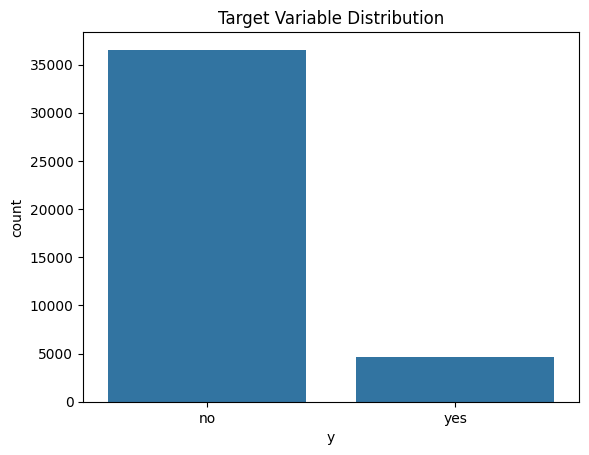

In [60]:
print("Target Variable Distribution:")
display(df['y'].value_counts())

sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

## 2. Data Preprocessing

In [61]:

df.replace('unknown', np.nan, inplace=True)
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in categorical_cols:
    if col != 'y':
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing 'unknown' values handled and categorical NaNs filled.")

Missing 'unknown' values handled and categorical NaNs filled.


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    return {'model_name': model_name, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}

In [63]:
results = []
log_reg = LogisticRegression(random_state=42, solver='liblinear')
results.append(train_evaluate_model(log_reg, X_train, y_train, X_test, y_test, "Logistic Regression"))
knn = KNeighborsClassifier(n_neighbors=5)
results.append(train_evaluate_model(knn, X_train, y_train, X_test, y_test, "K-Nearest Neighbors"))
svc = SVC(random_state=42, kernel='linear', C=0.1)
results.append(train_evaluate_model(svc, X_train, y_train, X_test, y_test, "Support Vector Machine"))

dec_tree = DecisionTreeClassifier(random_state=42)
results.append(train_evaluate_model(dec_tree, X_train, y_train, X_test, y_test, "Decision Tree Classifier"))

individual_model_results = pd.DataFrame(results)
display(individual_model_results)


--- Training Logistic Regression ---
Accuracy: 0.9153
Precision: 0.7018
Recall: 0.4310
F1-score: 0.5340

--- Training K-Nearest Neighbors ---
Accuracy: 0.9016
Precision: 0.5877
Recall: 0.4224
F1-score: 0.4915

--- Training Support Vector Machine ---
Accuracy: 0.9051
Precision: 0.6706
Recall: 0.3093
F1-score: 0.4233

--- Training Decision Tree Classifier ---
Accuracy: 0.8939
Precision: 0.5285
Recall: 0.5388
F1-score: 0.5336


,model_name,accuracy,precision,recall,f1_score
0,Logistic Regression,0.915271,0.701754,0.431034,0.534045
1,K-Nearest Neighbors,0.901554,0.587706,0.422414,0.491536
2,Support Vector Machine,0.905074,0.670561,0.309267,0.423304
3,Decision Tree Classifier,0.893906,0.528541,0.538793,0.533618


## 4. Apply Ensemble Learning Methods

In [64]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

ensemble_results = []
random_forest = RandomForestClassifier(random_state=42)
ensemble_results.append(train_evaluate_model(random_forest, X_train, y_train, X_test, y_test, "Random Forest"))
gradient_boosting = GradientBoostingClassifier(random_state=42)
ensemble_results.append(train_evaluate_model(gradient_boosting, X_train, y_train, X_test, y_test, "Gradient Boosting"))

ensemble_model_results = pd.DataFrame(ensemble_results)
display(ensemble_model_results)


--- Training Random Forest ---
Accuracy: 0.9192
Precision: 0.6997
Recall: 0.4946
F1-score: 0.5795

--- Training Gradient Boosting ---
Accuracy: 0.9202
Precision: 0.6869
Recall: 0.5366
F1-score: 0.6025


,model_name,accuracy,precision,recall,f1_score
0,Random Forest,0.919155,0.699695,0.494612,0.579545
1,Gradient Boosting,0.920248,0.686897,0.536638,0.602541


## 5. Model Evaluation and Comparison

In [65]:
print("\n--- Comparison of Individual and Ensemble Model Results ---")
all_model_results = pd.concat([individual_model_results, ensemble_model_results], ignore_index=True)
display(all_model_results.sort_values(by='f1_score', ascending=False))


--- Comparison of Individual and Ensemble Model Results ---


,model_name,accuracy,precision,recall,f1_score
5,Gradient Boosting,0.920248,0.686897,0.536638,0.602541
4,Random Forest,0.919155,0.699695,0.494612,0.579545
0,Logistic Regression,0.915271,0.701754,0.431034,0.534045
3,Decision Tree Classifier,0.893906,0.528541,0.538793,0.533618
1,K-Nearest Neighbors,0.901554,0.587706,0.422414,0.491536
2,Support Vector Machine,0.905074,0.670561,0.309267,0.423304


## 6. Model Selection and Interpretation

In [66]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
categorical_features_to_encode = [col for col in df.select_dtypes(include=['object']).columns if col != 'y']
df = pd.get_dummies(df, columns=categorical_features_to_encode, drop_first=True)

print("Target variable encoded and other categorical features one-hot encoded.")
display(df.head())

Target variable encoded and other categorical features one-hot encoded.


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
